In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [42]:
nav_df = pd.read_csv('../Data/Processed/nav_history_clean.csv')
nav_df.head()

,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239
3,2022-01-06,100016,515.7880
4,2022-01-07,100016,515.1639


In [43]:
nav_df.dtypes

date             str
amfi_code      int64
nav          float64
dtype: object

In [44]:
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(['amfi_code', 'date']).reset_index(drop=True)
nav_df.head()

,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239
3,2022-01-06,100016,515.7880
4,2022-01-07,100016,515.1639


In [45]:
print(nav_df['amfi_code'].nunique())
print(nav_df.shape)

40
(64320, 3)


In [46]:
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()
nav_df.head(10)

,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210
5,2022-01-08,100016,515.1639,0.000000
6,2022-01-09,100016,515.1639,0.000000
7,2022-01-10,100016,510.7136,-0.008639
8,2022-01-11,100016,513.5542,0.005562
9,2022-01-12,100016,512.3195,-0.002404


In [47]:
nav_df['daily_return'].describe()

count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

In [48]:
latest_date = nav_df['date'].max()
print(latest_date)

2026-05-29 00:00:00


In [49]:
def calculate_cagr(scheme_df, years, latest_date):
    start_date = latest_date - pd.DateOffset(years=years)
    scheme_df = scheme_df[scheme_df['date'] >= start_date]
    if len(scheme_df) < 2:
        return np.nan
    nav_start = scheme_df.iloc[0]['nav']
    nav_end = scheme_df.iloc[-1]['nav']
    actual_start_date = scheme_df.iloc[0]['date']
    actual_end_date = scheme_df.iloc[-1]['date']
    n_trading_days = len(scheme_df)
    n = n_trading_days / 252
    if n <= 0:
        return np.nan
    cagr = (nav_end / nav_start) ** (1/n) - 1
    return cagr

In [50]:
results = []

for amfi_code, scheme_df in nav_df.groupby('amfi_code'):
    scheme_df = scheme_df.sort_values('date')
    row = {'amfi_code': amfi_code}
    for years in [1, 3, 5]:
        row[f'cagr_{years}yr'] = calculate_cagr(scheme_df, years, latest_date)
    results.append(row)

cagr_df = pd.DataFrame(results)
cagr_df.head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.015368,0.008891,0.018109
1,100025,0.025365,0.026828,0.030531
2,100033,0.341586,0.213655,0.199081
3,101206,0.309411,0.191621,0.156906
4,101207,-0.172073,-0.028804,0.054086
5,101208,0.049282,0.043109,0.044439
6,102885,0.135103,0.131715,0.122412
7,102886,-0.118927,-0.005295,0.008065
8,102887,0.091654,0.169808,0.113289
9,118632,0.223130,0.151095,0.160205


In [51]:
cagr_df.isna().sum()

amfi_code    0
cagr_1yr     0
cagr_3yr     0
cagr_5yr     0
dtype: int64

In [52]:
cagr_df.head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.015368,0.008891,0.018109
1,100025,0.025365,0.026828,0.030531
2,100033,0.341586,0.213655,0.199081
3,101206,0.309411,0.191621,0.156906
4,101207,-0.172073,-0.028804,0.054086
5,101208,0.049282,0.043109,0.044439
6,102885,0.135103,0.131715,0.122412
7,102886,-0.118927,-0.005295,0.008065
8,102887,0.091654,0.169808,0.113289
9,118632,0.223130,0.151095,0.160205


In [53]:
history_check = nav_df.groupby('amfi_code')['date'].agg(['min', 'max'])
history_check['years_of_data'] = (history_check['max'] - history_check['min']).dt.days / 365.25
cagr_df = cagr_df.merge(history_check['years_of_data'], on='amfi_code')
cagr_df.head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,years_of_data
0,100016,-0.015368,0.008891,0.018109,4.399726
1,100025,0.025365,0.026828,0.030531,4.399726
2,100033,0.341586,0.213655,0.199081,4.399726
3,101206,0.309411,0.191621,0.156906,4.399726
4,101207,-0.172073,-0.028804,0.054086,4.399726
5,101208,0.049282,0.043109,0.044439,4.399726
6,102885,0.135103,0.131715,0.122412,4.399726
7,102886,-0.118927,-0.005295,0.008065,4.399726
8,102887,0.091654,0.169808,0.113289,4.399726
9,118632,0.223130,0.151095,0.160205,4.399726


In [54]:
risk_free_annual = 0.065
risk_free_daily = risk_free_annual / 252
print(risk_free_daily)

0.00025793650793650796


In [55]:
sharpe_results = []

for amfi_code, scheme_df in nav_df.groupby('amfi_code'):
    returns = scheme_df['daily_return'].dropna()
    mean_return = returns.mean()
    std_return = returns.std()
    sharpe = (mean_return - risk_free_daily) / std_return * np.sqrt(252)
    sharpe_results.append({'amfi_code': amfi_code, 'sharpe_ratio': sharpe})

sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df.head(10)

,amfi_code,sharpe_ratio
0,100016,-0.321019
1,100025,-1.039941
2,100033,0.808268
3,101206,0.717409
4,101207,0.052618
5,101208,-4.650401
6,102885,0.519797
7,102886,-0.294889
8,102887,0.384637
9,118632,0.758851


In [56]:
sharpe_df['sharpe_rank'] = sharpe_df['sharpe_ratio'].rank(ascending=False)
sharpe_df = sharpe_df.sort_values('sharpe_rank')
sharpe_df.head(10)

,amfi_code,sharpe_ratio,sharpe_rank
34,148567,1.068224,1.0
30,120843,0.965561,2.0
36,148569,0.919047,3.0
25,120505,0.883256,4.0
19,119551,0.860977,5.0
38,149323,0.832885,6.0
2,100033,0.808268,7.0
9,118632,0.758851,8.0
16,119094,0.730547,9.0
3,101206,0.717409,10.0


In [57]:
sortino_results = []

for amfi_code, scheme_df in nav_df.groupby('amfi_code'):
    returns = scheme_df['daily_return'].dropna()
    mean_return = returns.mean()
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std()
    sortino = (mean_return - risk_free_daily) / downside_std * np.sqrt(252)
    sortino_results.append({'amfi_code': amfi_code, 'sortino_ratio': sortino})

sortino_df = pd.DataFrame(sortino_results)
sortino_df.head(10)

,amfi_code,sortino_ratio
0,100016,-0.472822
1,100025,-1.461220
2,100033,1.144216
3,101206,1.063909
4,101207,0.075668
5,101208,-8.741654
6,102885,0.772972
7,102886,-0.420589
8,102887,0.571858
9,118632,1.098880


In [58]:
import os
os.listdir('../Data/Processed/')

['01_fund_master.csv',
 '03_aum_by_fund_house.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'alpha_beta.csv',
 'fund_scorecard.csv',
 'investor_transactions_clean.csv',
 'monthly_sip_inflows_clean.csv',
 'nav_history_clean.csv',
 'scheme_performance_clean.csv']

In [59]:
benchmark_df = pd.read_csv('../Data/Processed/10_benchmark_indices.csv')
benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [60]:
benchmark_df['index_name'].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [61]:
nifty100_df = benchmark_df[benchmark_df['index_name'] == 'NIFTY100'].copy()
nifty100_df['date'] = pd.to_datetime(nifty100_df['date'])
nifty100_df = nifty100_df.sort_values('date').reset_index(drop=True)
nifty100_df['benchmark_return'] = nifty100_df['close_value'].pct_change()
nifty100_df.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY100,17778.24,NaN
1,2022-01-04,NIFTY100,17537.52,-0.013540
2,2022-01-05,NIFTY100,17607.73,0.004003
3,2022-01-06,NIFTY100,17556.05,-0.002935
4,2022-01-07,NIFTY100,17664.02,0.006150


In [62]:
print(nifty100_df.shape)
print(nifty100_df['date'].min(), nifty100_df['date'].max())

(1150, 4)
2022-01-03 00:00:00 2026-05-29 00:00:00


In [63]:
merged_df = nav_df.merge(
    nifty100_df[['date', 'benchmark_return']],
    on='date',
    how='inner'
)
merged_df.head()

,date,amfi_code,nav,daily_return,benchmark_return
0,2022-01-03,100016,520.4608,NaN,NaN
1,2022-01-04,100016,515.0971,-0.010306,-0.013540
2,2022-01-05,100016,521.7239,0.012865,0.004003
3,2022-01-06,100016,515.7880,-0.011377,-0.002935
4,2022-01-07,100016,515.1639,-0.001210,0.006150


In [64]:
alpha_beta_results = []

for amfi_code, scheme_df in merged_df.groupby('amfi_code'):
    reg_data = scheme_df.dropna(subset=['daily_return', 'benchmark_return'])
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        reg_data['benchmark_return'], reg_data['daily_return']
    )
    beta = slope
    alpha = intercept * 252
    alpha_beta_results.append({
        'amfi_code': amfi_code,
        'alpha': alpha,
        'beta': beta,
        'r_squared': r_value ** 2
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df.head(10)

,amfi_code,alpha,beta,r_squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064
5,101208,0.060861,0.000267,0.000046
6,102885,0.170488,-0.019487,0.000383
7,102886,0.028969,-0.042125,0.000896
8,102887,0.162113,0.016683,0.000186
9,118632,0.218294,-0.008354,0.000058


In [65]:
alpha_beta_df['r_squared'].describe()

count    4.000000e+01
mean     6.087700e-04
std      7.265363e-04
min      1.345534e-07
25%      5.495723e-05
50%      3.455513e-04
75%      1.035467e-03
max      2.793007e-03
Name: r_squared, dtype: float64

In [66]:
nav_df['running_max'] = nav_df.groupby('amfi_code')['nav'].cummax()
nav_df['drawdown'] = nav_df['nav'] / nav_df['running_max'] - 1
nav_df.head(10)

,date,amfi_code,nav,daily_return,running_max,drawdown
0,2022-01-03,100016,520.4608,NaN,520.4608,0.000000
1,2022-01-04,100016,515.0971,-0.010306,520.4608,-0.010306
2,2022-01-05,100016,521.7239,0.012865,521.7239,0.000000
3,2022-01-06,100016,515.7880,-0.011377,521.7239,-0.011377
4,2022-01-07,100016,515.1639,-0.001210,521.7239,-0.012574
5,2022-01-08,100016,515.1639,0.000000,521.7239,-0.012574
6,2022-01-09,100016,515.1639,0.000000,521.7239,-0.012574
7,2022-01-10,100016,510.7136,-0.008639,521.7239,-0.021104
8,2022-01-11,100016,513.5542,0.005562,521.7239,-0.015659
9,2022-01-12,100016,512.3195,-0.002404,521.7239,-0.018026


In [67]:
max_drawdown_results = []

for amfi_code, scheme_df in nav_df.groupby('amfi_code'):
    worst_row = scheme_df.loc[scheme_df['drawdown'].idxmin()]
    max_drawdown_results.append({
        'amfi_code': amfi_code,
        'max_drawdown': worst_row['drawdown'],
        'drawdown_date': worst_row['date']
    })

max_drawdown_df = pd.DataFrame(max_drawdown_results)
max_drawdown_df.head(10)

,amfi_code,max_drawdown,drawdown_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11
5,101208,-0.001622,2023-09-12
6,102885,-0.108599,2022-03-29
7,102886,-0.280011,2026-04-27
8,102887,-0.215398,2022-07-04
9,118632,-0.174141,2024-07-19


In [68]:
fund_master_df = pd.read_csv('../Data/Processed/01_fund_master.csv')
fund_master_df.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [69]:
scorecard_df = cagr_df[['amfi_code', 'cagr_3yr']].merge(
    sharpe_df[['amfi_code', 'sharpe_ratio']], on='amfi_code'
).merge(
    alpha_beta_df[['amfi_code', 'alpha']], on='amfi_code'
).merge(
    fund_master_df[['amfi_code', 'expense_ratio_pct']], on='amfi_code'
).merge(
    max_drawdown_df[['amfi_code', 'max_drawdown']], on='amfi_code'
)
scorecard_df.head(10)

,amfi_code,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown
0,100016,0.008891,-0.321019,0.037476,1.55,-0.247344
1,100025,0.026828,-1.039941,0.042818,0.56,-0.043083
2,100033,0.213655,0.808268,0.271954,1.38,-0.162172
3,101206,0.191621,0.717409,0.213998,1.60,-0.112916
4,101207,-0.028804,0.052618,0.108971,1.53,-0.354469
5,101208,0.043109,-4.650401,0.060861,0.79,-0.001622
6,102885,0.131715,0.519797,0.170488,1.57,-0.108599
7,102886,-0.005295,-0.294889,0.028969,1.51,-0.280011
8,102887,0.169808,0.384637,0.162113,1.64,-0.215398
9,118632,0.151095,0.758851,0.218294,1.51,-0.174141


In [70]:
scorecard_df['return_score'] = scorecard_df['cagr_3yr'].rank(pct=True) * 100
scorecard_df['sharpe_score'] = scorecard_df['sharpe_ratio'].rank(pct=True) * 100
scorecard_df['alpha_score'] = scorecard_df['alpha'].rank(pct=True) * 100
scorecard_df['expense_score'] = scorecard_df['expense_ratio_pct'].rank(pct=True, ascending=False) * 100
scorecard_df['drawdown_score'] = scorecard_df['max_drawdown'].rank(pct=True) * 100
scorecard_df.head(10)

,amfi_code,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,return_score,sharpe_score,alpha_score,expense_score,drawdown_score
0,100016,0.008891,-0.321019,0.037476,1.55,-0.247344,15.0,17.5,5.0,22.50,17.5
1,100025,0.026828,-1.039941,0.042818,0.56,-0.043083,17.5,10.0,7.5,97.50,92.5
2,100033,0.213655,0.808268,0.271954,1.38,-0.162172,92.5,85.0,87.5,60.00,52.5
3,101206,0.191621,0.717409,0.213998,1.60,-0.112916,80.0,77.5,72.5,11.25,80.0
4,101207,-0.028804,0.052618,0.108971,1.53,-0.354469,5.0,35.0,35.0,31.25,7.5
5,101208,0.043109,-4.650401,0.060861,0.79,-0.001622,25.0,2.5,20.0,75.00,95.0
6,102885,0.131715,0.519797,0.170488,1.57,-0.108599,57.5,62.5,55.0,17.50,85.0
7,102886,-0.005295,-0.294889,0.028969,1.51,-0.280011,10.0,20.0,2.5,41.25,15.0
8,102887,0.169808,0.384637,0.162113,1.64,-0.215398,70.0,47.5,50.0,3.75,27.5
9,118632,0.151095,0.758851,0.218294,1.51,-0.174141,67.5,82.5,75.0,41.25,45.0


In [71]:
scorecard_df['fund_score'] = (
    0.30 * scorecard_df['return_score'] +
    0.25 * scorecard_df['sharpe_score'] +
    0.20 * scorecard_df['alpha_score'] +
    0.15 * scorecard_df['expense_score'] +
    0.10 * scorecard_df['drawdown_score']
)

scorecard_df = scorecard_df.merge(fund_master_df[['amfi_code', 'scheme_name']], on='amfi_code')
scorecard_df = scorecard_df.sort_values('fund_score', ascending=False).reset_index(drop=True)
scorecard_df[['amfi_code', 'scheme_name', 'fund_score']].head(10)

,amfi_code,scheme_name,fund_score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,86.2500
1,120505,ICICI Pru Midcap Fund - Regular - Growth,82.8750
2,120843,Kotak Flexicap Fund - Regular - Growth,82.0000
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.7500
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,79.3750
5,119094,Axis Midcap Fund - Regular - Growth,78.2500
6,119551,SBI Bluechip Fund - Regular Plan - Growth,74.1875
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,73.6875
8,119598,SBI Small Cap Fund - Regular Plan - Growth,68.0000
9,101206,ABSL Frontline Equity Fund - Regular - Growth,67.5625


In [72]:
top5_codes = scorecard_df.head(5)['amfi_code'].tolist()
print(top5_codes)

[148567, 120505, 120843, 100033, 120504]


In [73]:
three_yr_start = latest_date - pd.DateOffset(years=3)

def build_cumulative_series(df, value_col, filter_col, filter_val, start_date):
    series = df[(df[filter_col] == filter_val) & (df['date'] >= start_date)].copy()
    series = series.sort_values('date')
    series['cumulative_return'] = series[value_col] / series[value_col].iloc[0]
    return series[['date', 'cumulative_return']]

In [74]:
benchmark_df['date'] = pd.to_datetime(benchmark_df['date'])

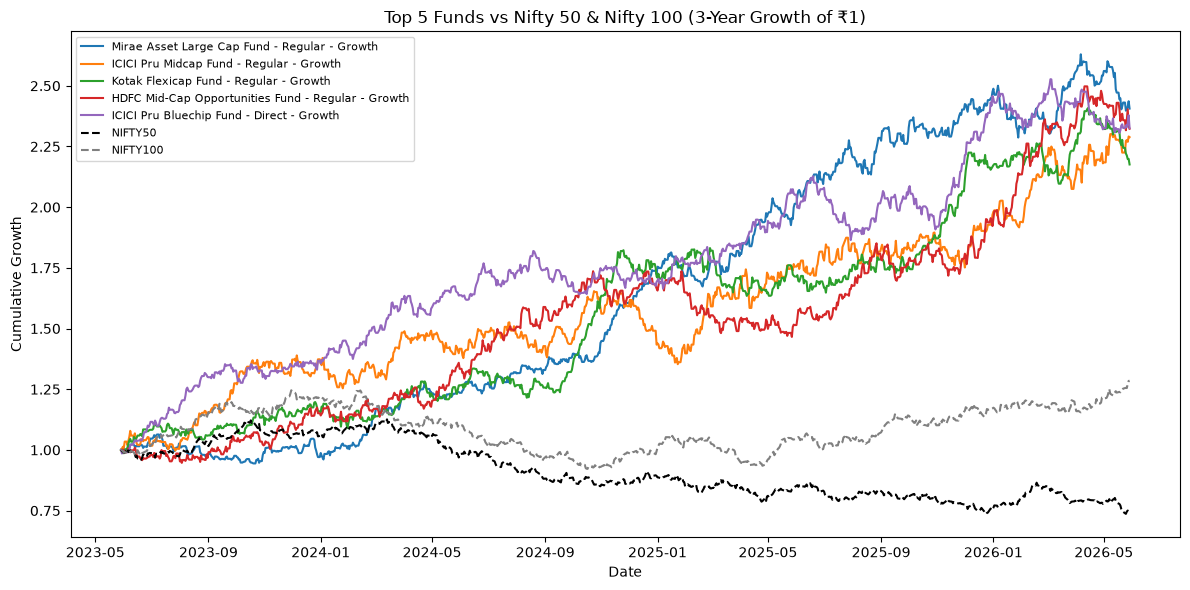

In [75]:
plt.figure(figsize=(12, 6))

for code in top5_codes:
    fund_series = build_cumulative_series(nav_df, 'nav', 'amfi_code', code, three_yr_start)
    fund_name = fund_master_df[fund_master_df['amfi_code'] == code]['scheme_name'].values[0]
    plt.plot(fund_series['date'], fund_series['cumulative_return'], label=fund_name)

nifty50_series = build_cumulative_series(benchmark_df, 'close_value', 'index_name', 'NIFTY50', three_yr_start)
plt.plot(nifty50_series['date'], nifty50_series['cumulative_return'], label='NIFTY50', linestyle='--', color='black')

nifty100_series = build_cumulative_series(benchmark_df, 'close_value', 'index_name', 'NIFTY100', three_yr_start)
plt.plot(nifty100_series['date'], nifty100_series['cumulative_return'], label='NIFTY100', linestyle='--', color='gray')

plt.title('Top 5 Funds vs Nifty 50 & Nifty 100 (3-Year Growth of ₹1)')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/charts/benchmark_comparison.png', dpi=150)
plt.show()

In [76]:
tracking_error_results = []

for code in top5_codes:
    fund_returns = nav_df[(nav_df['amfi_code'] == code) & (nav_df['date'] >= three_yr_start)][['date', 'daily_return']]
    bench_returns = nifty100_df[nifty100_df['date'] >= three_yr_start][['date', 'benchmark_return']]
    
    merged = fund_returns.merge(bench_returns, on='date').dropna()
    diff = merged['daily_return'] - merged['benchmark_return']
    tracking_error = diff.std() * np.sqrt(252)
    
    fund_name = fund_master_df[fund_master_df['amfi_code'] == code]['scheme_name'].values[0]
    tracking_error_results.append({'amfi_code': code, 'scheme_name': fund_name, 'tracking_error': tracking_error})

tracking_error_df = pd.DataFrame(tracking_error_results)
tracking_error_df

,amfi_code,scheme_name,tracking_error
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.187867
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.232515
2,120843,Kotak Flexicap Fund - Regular - Growth,0.206410
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.224838
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.187312


In [77]:
scorecard_df[['amfi_code', 'scheme_name', 'return_score', 'sharpe_score', 'alpha_score', 
              'expense_score', 'drawdown_score', 'fund_score']].to_csv(
    '../Data/Processed/fund_scorecard.csv', index=False
)

alpha_beta_df.to_csv('../Data/Processed/alpha_beta.csv', index=False)

print("Saved fund_scorecard.csv and alpha_beta.csv")

Saved fund_scorecard.csv and alpha_beta.csv


## Day 4 — Performance Analytics: Key Insights

1. **Top overall fund:** Mirae Asset Large Cap Fund (148567) leads the scorecard with a score of 86.25/100, driven by the highest Sharpe Ratio (1.068) among all 40 funds.

2. **Data span limitation:** All funds have ~4.4 years of NAV history (2022-01-03 to 2026-05-29), not the full 5 years. "5yr CAGR" figures reflect this shorter actual window — computed using true elapsed days, not a fixed 5-year assumption.

3. **Alpha/Beta regression caveat:** R² values against Nifty 100 are near-zero across all 40 funds (mean ≈ 0.0006, max ≈ 0.0028). This indicates the synthetic dataset does not encode realistic market-correlation structure — Alpha/Beta results are computed correctly but should not be interpreted as real-world fund behavior.

4. **Outlier fund:** Scheme 101208 shows extreme Sharpe (-4.65) and Sortino (-8.74) ratios due to very low volatility combined with a negative mean return — flagged for review rather than treated as a genuine top/bottom performer.

5. **Top 5 funds outperform benchmarks:** Over the trailing 3 years, all top-5 scorecard funds grew to 2.2x–2.7x, while Nifty 50 fell to ~0.75x and Nifty 100 rose modestly to ~1.25x — consistent with the near-zero correlation finding above.

6. **Tracking error:** Ranges from 18.7%–23.3% across the top 5 funds, reflecting their high divergence from the Nifty 100 benchmark.